#### Print your name

In [5]:
## Your code here 
print("Exercise by: Heidi Putkuri")

Exercise by: Heidi Putkuri


# Compare fully connected network vs. convolution network performance

In this notebook, you'll compare 3 different neural network with same parameter count. First we start with fully connected network (FC), then we try convolutinal network (CNN) and finally we try pretrained densenet (also CNN).

We try to make all networks with same parameter count (= 7...8M parameters). Target size you can find from densenet description below. 

<img src='../data/assets/densenet121.png' width=600>

https://pytorch.org/vision/main/models/generated/torchvision.models.densenet121.html

**Note.** Running 6 epochs with all these 3 networks takes some time, about 25 min / network. 


In [6]:
import matplotlib.pyplot as plt
import time

import torch
from torch import nn
from torch import optim
import torch.nn.functional as F
from torchvision import datasets, transforms, models

print(torch.cuda.is_available())
print(torch.__version__)

if torch.cuda.is_available() :
    device = "cuda" 
else : 
    device = "cpu" 

print("Device =", device)

False
2.5.1
Device = cpu


In [7]:
def count_trainable_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def count_parameters(model):
    return sum(p.numel() for p in model.parameters())

In [8]:
BATCH_SIZE = 256
EPOCHS = 6

***
### Exercise - Data loaders:
Define needed transforms for training images and testing images.

**Use parameters:**
- mini-batch size = BATCH_SIZE
- Use normalization: means `[0.485, 0.456, 0.406]` and the stds `[0.229, 0.224, 0.225]`
- image size: 224x224 pixels

In [ ]:
## Task 1:
## Your code here 
path_train = '../data/Cat_Dog_data/train'
path_test = '../data/Cat_Dog_data/test'
train_transforms = transforms.Compose([transforms.RandomRotation(30),
                                        transforms.RandomResizedCrop(224), # this makes the image 224x224
                                        transforms.RandomHorizontalFlip(),
                                        transforms.ToTensor(),
                                        transforms.Normalize([0.485, 0.456, 0.406],
                                                            [0.229, 0.224, 0.225])])
train_data = datasets.ImageFolder(path_train, transform=train_transforms)
trainloader = torch.utils.data.DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)

test_transforms = transforms.Compose([transforms.Resize(255),
                                        transforms.CenterCrop(224),
                                        transforms.ToTensor(),
                                        transforms.Normalize([0.485, 0.456, 0.406],
                                                                [0.229, 0.224, 0.225])])
test_data = datasets.ImageFolder(path_test, transform=test_transforms)
testloader = torch.utils.data.DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=True)


In [17]:
for images, labels in trainloader:
    print("Batch image shape:", images.shape)  # Should print (batch_size, 3, 224, 224)
    break

Batch image shape: torch.Size([256, 3, 224, 224])


***
### Exercise - Train function:
Define train function to train the model.

```python
def train_model(model, device, epochs) :

```

In [ ]:
## Task 2:
## Your code here 
def train_model(model: nn.Module, device: str, epochs: int):
    print("Starting training")
    start_time = time.time()
    model.to(device)
    criterion = nn.NLLLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    train_losses = []
    test_losses = []
    train_accuracies = []
    test_accuracies = []

    for e in range(epochs):
        model.train()
        running_loss = 0
        train_correct = 0
        total_samples = 0
        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            output = model(images) # Make predictions
            loss = criterion(output, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            _, predicted = torch.max(output, 1)
            train_correct += torch.sum(predicted == labels).item()
            total_samples += labels.size(0)
            
        #train_losses.append(running_loss / len(trainloader))
        train_loss = running_loss / len(trainloader)
        train_losses.append(train_loss)
        train_accuracy = train_correct / total_samples
        train_accuracies.append(train_accuracy)
    
        test_loss = 0
        test_correct = 0
        total_test = 0
        #validation
        with torch.no_grad():
            model.eval()
            for images, labels in testloader:
                images, labels = images.to(device), labels.to(device)
                output = model(images)
                test_loss += criterion(output, labels).item()
                _, y_pred = torch.max(output, 1)
                test_correct += torch.sum(y_pred == labels).item()
                total_test += labels.size(0)
                
        test_loss = test_loss / len(testloader)
        test_accuracy = test_correct / total_test
        test_losses.append(test_loss)
        test_accuracies.append(test_accuracy)

        print(f"Epoch: {e}, Loss = {train_loss:.3f}, "
                f"Train Accuracy = {train_accuracy:.3f}, "
                f"Test Loss = {test_loss:.3f}, "
                f"Test Accuracy = {test_accuracy:.3f}")

    print("Finished training")
    training_time_seconds = time.time() - start_time
    minutes, seconds = divmod(training_time_seconds, 60)
    print(f"Training time is: {int(minutes)} minutes and {seconds} seconds")

    return train_losses, train_accuracies, test_losses, test_accuracies

***
### Exercise - 1. Fully connected network 
Define and train fully connected network with 3-5 layers and total ~ 8M parameters. 

**Print following parameters:**
- Model parameter count 
- training time
- Save results to following parameters: 
`fc_train_losses, fc_train_accuracy, fc_test_losses, fc_test_accuracy`

***Hint.*** You can use function `count_parameters(model)` to check the model size. 

In [87]:
## Task 3:
## Your code here 
class FullyConnectedNN(nn.Module):

    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(224 * 224 * 3, 48)
        self.fc2 = nn.Linear(48,24)
        self.fc3 = nn.Linear(24, 12)
        self.fc4 = nn.Linear(12, 2)
        

    def forward(self, x):
        x = x.view(x.shape[0], -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = F.log_softmax(self.fc4(x), dim=1)
        return x # log_softmax for NLLLoss

In [88]:
fcmodel = FullyConnectedNN()
print(f"Fully connected network parameters: {count_parameters(fcmodel):}")
print(f"Fully connected network trainable parameters: {count_parameters(fcmodel):}")

Fully connected network parameters: 7226894
Fully connected network trainable parameters: 7226894


In [8]:
fc_train_losses, fc_train_accuracies, fc_test_losses, fc_test_accuracies = train_model(fcmodel, device, epochs=EPOCHS)

Epoch 0, Loss = 0.953669, Accuracy = 0.504883,  Test loss = 0.704039,  Test accuracy = 0.575484
Epoch 1, Loss = 0.731208, Accuracy = 0.542658,  Test loss = 0.695503,  Test accuracy = 0.567170
Epoch 2, Loss = 0.710245, Accuracy = 0.545765,  Test loss = 0.685547,  Test accuracy = 0.584084
Epoch 3, Loss = 0.702436, Accuracy = 0.554332,  Test loss = 0.682599,  Test accuracy = 0.579432
Epoch 4, Loss = 0.691874, Accuracy = 0.561124,  Test loss = 0.667037,  Test accuracy = 0.588961
Epoch 5, Loss = 0.684469, Accuracy = 0.569824,  Test loss = 0.666031,  Test accuracy = 0.594347
Finished Training
Training time is:25m 33s


### Exercise - 2. Convolutional network
Define and convolutional network with 3-5 convolution layers and total ~ 8M parameters. 

**Print following parameters:**
- Model parameter count
- training time
- Save results to following parameters: 
`conv_train_losses, conv_train_accuracy, conv_test_losses, conv_test_accuracy`

***Hint.*** You can use function `count_parameters(model)` to check the model size. 

In [ ]:
## Task 4:
## Your code here

class ConvolutionalNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        # 4 conv layers
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)  
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(128, 284, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1 = nn.Linear(284 * 14 * 14, 148)
        self.fc2 = nn.Linear(148, 2)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = self.pool(F.relu(self.conv4(x)))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return F.log_softmax(x, dim=1)

convmodel = ConvolutionalNetwork()

print(f"Convolutional network parameters: {count_parameters(convmodel):,}")

print(f"Convolutional network trainable parameters: {count_parameters(convmodel):,}")


Convolutional network parameters: 7,015,178
Convolutional network trainable parameters: 7,015,178


In [10]:
conv_train_losses, conv_train_accuracies, conv_test_losses, conv_test_accuracies = train_model(convmodel, device, EPOCHS)

Epoch 0, Loss = 0.690286, Accuracy = 0.559348,  Test loss = 0.649131,  Test accuracy = 0.618258
Epoch 1, Loss = 0.655468, Accuracy = 0.608132,  Test loss = 0.611315,  Test accuracy = 0.663099
Epoch 2, Loss = 0.615912, Accuracy = 0.656339,  Test loss = 0.551965,  Test accuracy = 0.713767
Epoch 3, Loss = 0.573775, Accuracy = 0.697399,  Test loss = 0.511544,  Test accuracy = 0.756492
Epoch 4, Loss = 0.548584, Accuracy = 0.720126,  Test loss = 0.500708,  Test accuracy = 0.760083
Epoch 5, Loss = 0.541474, Accuracy = 0.718750,  Test loss = 0.462479,  Test accuracy = 0.783600
Finished Training
Training time is:25m 58s


### Exercise - 3. densenet121
Define and train fully connected network with 3-5 layers and total ~ 8M parameters. 

**Print following parameters:**
- Model parameter count
- training time
- Save results to following parameters: 
`dense_train_losses, dense_train_accuracy, dense_test_losses, dense_test_accuracy`

***Hint.*** You can use function `count_parameters(model)` to check the model size. 

In [ ]:
## Task 5:
## Your code here 

class DenseModel(nn.Module):
    def __init__(self, num_classes=2):
        super(DenseModel, self).__init__()
        self.dense_model = models.densenet121(weights='DEFAULT')
        
        for param in self.dense_model.features.parameters(): # Freeze the feature parameters
            param.requires_grad = False

        self.dense_model.classifier = nn.Sequential(
            nn.Linear(1024, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.dense_model.features(x) # Pass through the feature extractor, to get [batch, 1024, 7, 7]
        x = F.relu(x, inplace=True)
        x = F.adaptive_avg_pool2d(x, (1, 1))
        x = torch.flatten(x, 1)
        x = self.dense_model.classifier(x)
        return F.log_softmax(x, dim=1)

densemodel = DenseModel()

print(f"Dense network parameters: {count_parameters(densemodel):,}")

print(f"Dense network trainable parameters: {count_parameters(densemodel):,}")


Dense network parameters: 7216770
Dense network trainable parameters: 262914


In [12]:
dense_train_losses, dense_train_accuracies, dense_test_losses, dense_test_accuracies = train_model(densemodel, device, EPOCHS)

Epoch 0, Loss = 0.182689, Accuracy = 0.917125,  Test loss = 0.042019,  Test accuracy = 0.982696
Epoch 1, Loss = 0.150390, Accuracy = 0.934038,  Test loss = 0.045249,  Test accuracy = 0.982422
Epoch 2, Loss = 0.126949, Accuracy = 0.944114,  Test loss = 0.042253,  Test accuracy = 0.986368
Epoch 3, Loss = 0.130450, Accuracy = 0.941628,  Test loss = 0.041337,  Test accuracy = 0.983984
Epoch 4, Loss = 0.118166, Accuracy = 0.945268,  Test loss = 0.035377,  Test accuracy = 0.985938
Epoch 5, Loss = 0.120742, Accuracy = 0.944513,  Test loss = 0.034920,  Test accuracy = 0.986328
Finished Training
Training time is:28m 1s


### Exercise - Results


Text(0.5, 1.0, 'Test accuracy')

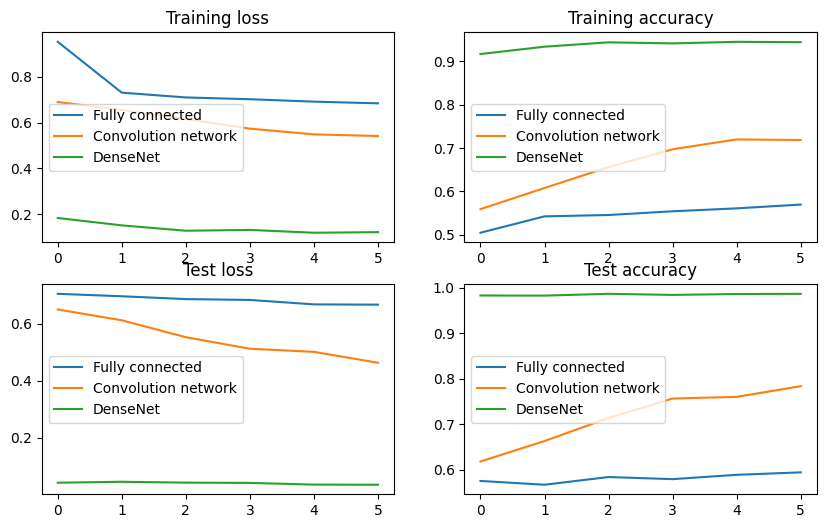

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.subplot(2, 2, 1)
plt.plot(fc_train_losses)
plt.plot(conv_train_losses)
plt.plot(dense_train_losses)
plt.legend(['Fully connected', 'Convolution network', 'DenseNet'])
plt.title('Training loss')

plt.subplot(2, 2, 2)
plt.plot((fc_train_accuracies))
plt.plot(conv_train_accuracies)
plt.plot(dense_train_accuracies)
plt.legend(['Fully connected', 'Convolution network', 'DenseNet'])
plt.title('Training accuracy')

plt.subplot(2, 2, 3)
plt.plot(fc_test_losses)
plt.plot(conv_test_losses)
plt.plot(dense_test_losses)
plt.legend(['Fully connected', 'Convolution network', 'DenseNet'])
plt.title('Test loss')

plt.subplot(2, 2, 4)
plt.plot((fc_test_accuracies))
plt.plot(conv_test_accuracies)
plt.plot(dense_test_accuracies)
plt.legend(['Fully connected', 'Convolution network', 'DenseNet'])
plt.title('Test accuracy')


***

## Reflection

Answer briefly following questions (in English or Finnish):
- Which model is best? Why?
- Is there some topics that should have been checked? E.g. training with more epochs?


The model using the pretrained DenseNet is the best, as shown by its higher accuracy and lower loss compared to the Fully Connected and Convolutional models. The pretrained model benefits from being trained on a large-scale dataset, allowing it to extract more meaningful features and generalize better to new data.

The convolutional model could be trained with more epochs to see if the accuracy would increase and loss decrease more, like it looks like when observing the plot. 

### Great work!